<h2>MLP Neural Network for Instagram Engagement Classification<h2>

- Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

/kaggle/input/datasets/sadiajavedd/social-media-user-activity-dataset/instagram_usage_lifestyle.csv


# Load Dataset

In [31]:
df = pd.read_csv('/kaggle/input/datasets/sadiajavedd/social-media-user-activity-dataset/instagram_usage_lifestyle.csv')
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


# EDA<br>
- Dataset Overview

In [32]:
print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Size: 1547896 rows, 58 columns


In [33]:
print("\nData Types:\n", df.dtypes)


Data Types:
 user_id                             int64
app_name                           object
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                       object
employment_status                  object
education_level                    object
relationship_status                object
has_children                       object
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                       object
smoking                            object
alcohol_frequency                  object
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64
hobbies_count       

In [34]:
print("\nMissing Values:\n", df.isna().sum())


Missing Values:
 user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_fre

In [35]:
print("\nBasic Statistics:\n")
df.describe()


Basic Statistics:



,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,7.739485e+05,3.898544e+01,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,...,3.762037e+01,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,5.002404e-01,2.017501e+03,2.050971e+01,1.975254e+00,1.644642e+00
std,4.468392e+05,1.529453e+01,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,...,2.535788e+01,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,2.887827e-01,4.611735e+00,8.697454e+00,1.352058e+00,1.812684e+00
min,1.000000e+00,1.300000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,2.000000e+01,0.000000e+00,2.010000e+03,5.000000e+00,0.000000e+00,6.700000e-01
25%,3.869748e+05,2.600000e+01,4.000000e+00,6.300000e+00,1.000000e+01,3.000000e+00,2.230000e+01,1.070000e+02,7.000000e+01,7.940000e+03,...,1.800000e+01,1.600000e+01,2.900000e+01,5.430000e+02,6.630000e+02,2.500000e-01,2.013000e+03,1.330000e+01,1.000000e+00,1.000000e+00
50%,7.739485e+05,3.900000e+01,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,2.500000e+01,1.240000e+02,7.900000e+01,8.000000e+03,...,3.400000e+01,3.100000e+01,5.400000e+01,1.154000e+03,1.519000e+03,5.000000e-01,2.017000e+03,2.040000e+01,2.000000e+00,1.100000e+00
75%,1.160922e+06,5.200000e+01,9.700000e+00,7.700000e+00,3.000000e+01,8.000000e+00,2.770000e+01,1.420000e+02,9.000000e+01,8.060000e+03,...,5.300000e+01,4.700000e+01,8.000000e+01,2.459000e+03,3.451000e+03,7.500000e-01,2.022000e+03,2.760000e+01,3.000000e+00,1.290000e+00
max,1.547896e+06,6.500000e+01,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,4.500000e+01,1.590000e+02,9.900000e+01,8.473000e+03,...,1.710000e+02,1.380000e+02,2.220000e+02,2.088110e+05,1.000000e+04,1.000000e+00,2.025000e+03,5.200000e+01,5.000000e+00,1.867000e+01


- Class distribution of engagement score

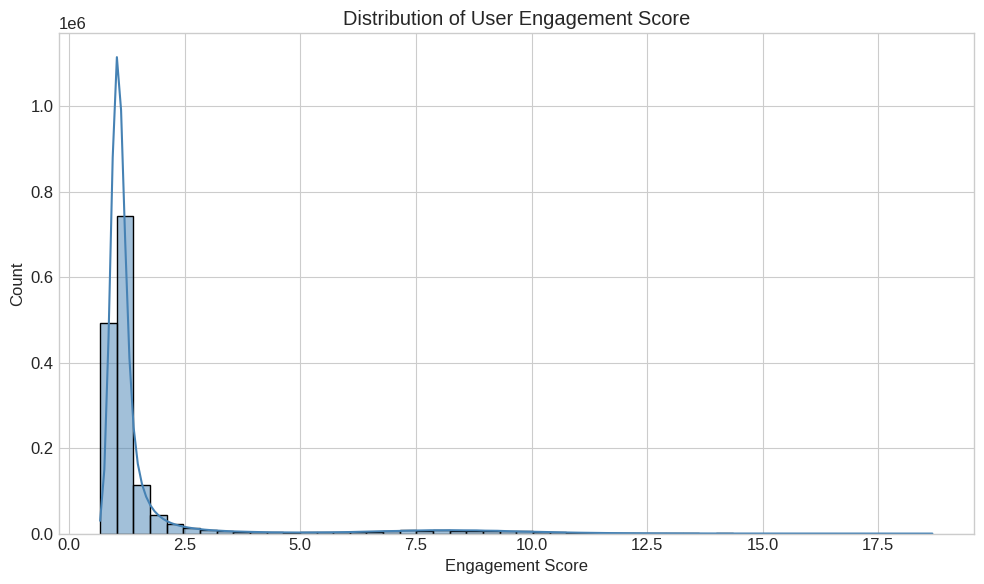

In [36]:
plt.figure()
sns.histplot(df['user_engagement_score'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of User Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


- Correlation heatmap (top features only for readability)

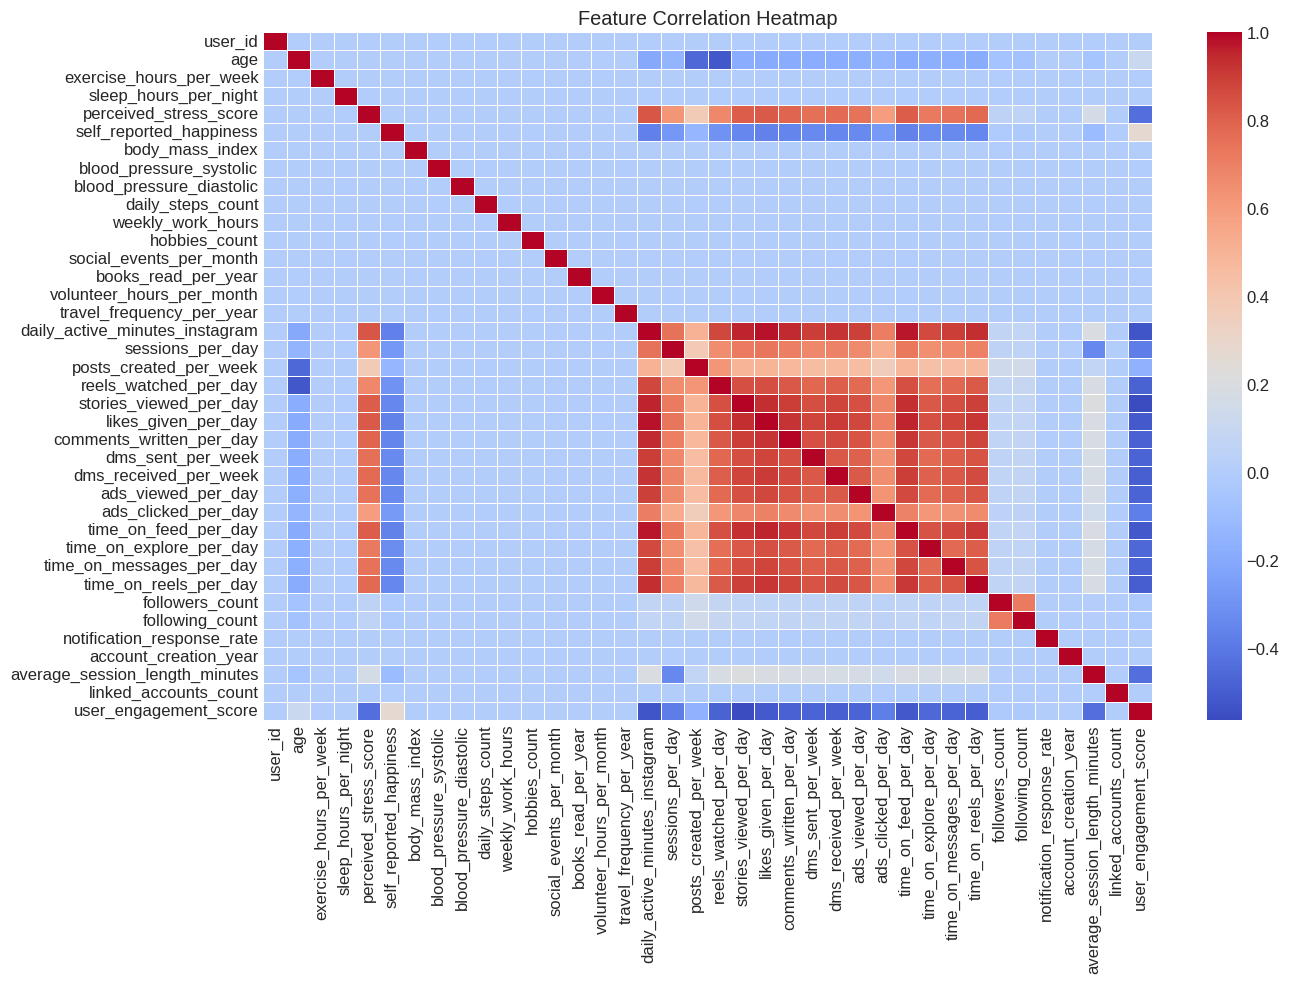

In [37]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

- Engagement score vs followers

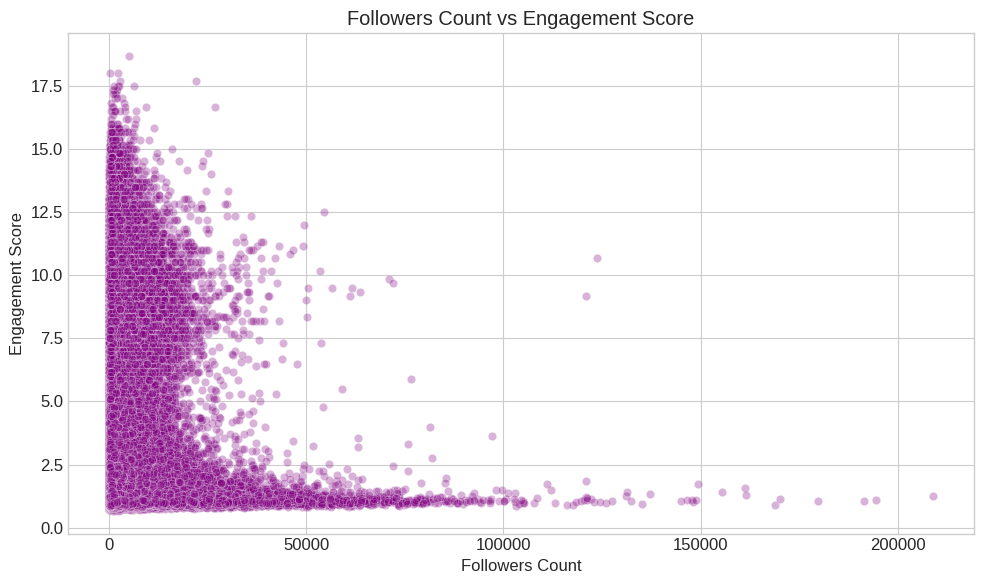

In [38]:
plt.figure()
sns.scatterplot(data=df, x='followers_count', y='user_engagement_score', alpha=0.3, color='purple')
plt.title('Followers Count vs Engagement Score')
plt.xlabel('Followers Count')
plt.ylabel('Engagement Score')
plt.tight_layout()
plt.show()

- Engagement score vs posts per week

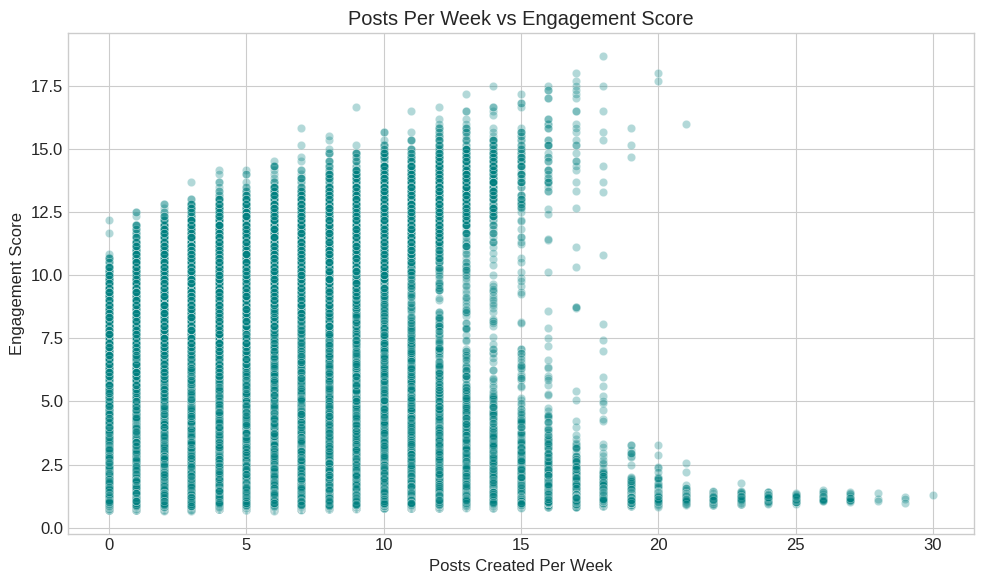

In [39]:
plt.figure()
sns.scatterplot(data=df, x='posts_created_per_week', y='user_engagement_score', alpha=0.3, color='teal')
plt.title('Posts Per Week vs Engagement Score')
plt.xlabel('Posts Created Per Week')
plt.ylabel('Engagement Score')
plt.tight_layout()
plt.show()

# Preprocessing

- drop irrelevant columns

In [40]:
df.drop(columns=['user_id', 'app_name', 'last_login_date'], inplace=True, errors='ignore')

- Encode categorical columns

In [41]:
cat_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns to encode: {list(cat_cols)}")
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

Categorical columns to encode: ['gender', 'country', 'urban_rural', 'income_level', 'employment_status', 'education_level', 'relationship_status', 'has_children', 'diet_quality', 'smoking', 'alcohol_frequency', 'uses_premium_features', 'content_type_preference', 'preferred_content_theme', 'privacy_setting_level', 'two_factor_auth_enabled', 'biometric_login_used', 'subscription_status']


# Feature Engineering

- create the following features based on the existing features: <br>
1. Engagement rate (engagement score / followers)
2. Posting intensity (posts per week / active minutes)
3. Interaction score (likes + comments + dms sent)
4. Content consumption ratio (reels + stories viewed)
5. Time on platform total

In [42]:
df['engagement_rate'] = df['user_engagement_score'] / (df['followers_count'] + 1)
df['posting_intensity'] = df['posts_created_per_week'] / (df['daily_active_minutes_instagram'] + 1)
df['interaction_score'] = df['likes_given_per_day'] + df['comments_written_per_day'] + df['dms_sent_per_week']
df['content_consumption'] = df['reels_watched_per_day'] + df['stories_viewed_per_day']
df['total_time_on_platform'] = (df['time_on_feed_per_day'] + df['time_on_explore_per_day'] + 
                                 df['time_on_reels_per_day'] + df['time_on_messages_per_day'])
print("New engineered features added:")
print(['engagement_rate', 'posting_intensity', 'interaction_score', 
       'content_consumption', 'total_time_on_platform'])

New engineered features added:
['engagement_rate', 'posting_intensity', 'interaction_score', 'content_consumption', 'total_time_on_platform']


- Create Binary Target

In [43]:
threshold = df['user_engagement_score'].quantile(0.90)
df['viral'] = (df['user_engagement_score'] >= threshold).astype(int)
print(f"\nViral threshold (90th percentile): {threshold:.2f}")
print("Class distribution:")
print(df['viral'].value_counts())
print(f"Viral ratio: {df['viral'].mean():.2%}")


Viral threshold (90th percentile): 2.12
Class distribution:
viral
0    1392991
1     154905
Name: count, dtype: int64
Viral ratio: 10.01%


- There is heavy target class imbalance, use Random Oversampling to ensure target classes are balanced.

In [44]:
df_majority = df[df['viral'] == 0]
df_minority = df[df['viral'] == 1]

df_majority_downsampled = df_majority.sample(n=len(df_minority), random_state=42) #undersample majority to match minority count

df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True) #combine and shuffle

In [45]:
print("Balanced class distribution:")
print(df_balanced['viral'].value_counts())

Balanced class distribution:
viral
1    154905
0    154905
Name: count, dtype: int64


In [46]:
x = df_balanced.drop(columns=['viral'])
y = df_balanced['viral']

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

- Scale Features

In [48]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(f"Train size: {x_train.shape}")
print(f"Test size: {x_test.shape}")

Train size: (247848, 60)
Test size: (61962, 60)


# Model Training using MLPClassifier

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), #3 hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001, #L2 regularization
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True, #to stop if val loss stops improving
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

In [50]:
mlp.fit(x_train, y_train)

print(f"\nTraining complete!")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Best validation score: {mlp.best_validation_score_:.4f}")

Iteration 1, loss = 0.03570047
Validation score: 0.992374
Iteration 2, loss = 0.01668134
Validation score: 0.990680
Iteration 3, loss = 0.01321246
Validation score: 0.995118
Iteration 4, loss = 0.01129349
Validation score: 0.992980
Iteration 5, loss = 0.01005402
Validation score: 0.993867
Iteration 6, loss = 0.00868884
Validation score: 0.995602
Iteration 7, loss = 0.00855670
Validation score: 0.995199
Iteration 8, loss = 0.00753954
Validation score: 0.994997
Iteration 9, loss = 0.00709774
Validation score: 0.995925
Iteration 10, loss = 0.00596604
Validation score: 0.995037
Iteration 11, loss = 0.00616339
Validation score: 0.996046
Iteration 12, loss = 0.00559719
Validation score: 0.995925
Iteration 13, loss = 0.00503274
Validation score: 0.995925
Iteration 14, loss = 0.00497422
Validation score: 0.996046
Iteration 15, loss = 0.00457141
Validation score: 0.995764
Iteration 16, loss = 0.00477662
Validation score: 0.996046
Iteration 17, loss = 0.00447270
Validation score: 0.995602
Iterat

# Model Evaluation

- Standard metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC)

In [51]:
y_pred = mlp.predict(x_test)
y_prob = mlp.predict_proba(x_test)[:, 1]

print("MLP Classifier - Test Results")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

MLP Classifier - Test Results
Accuracy:  0.9961
Precision: 0.9941
Recall:    0.9982
F1-Score:  0.9961
ROC-AUC:   0.9999


- Confusion Matrix

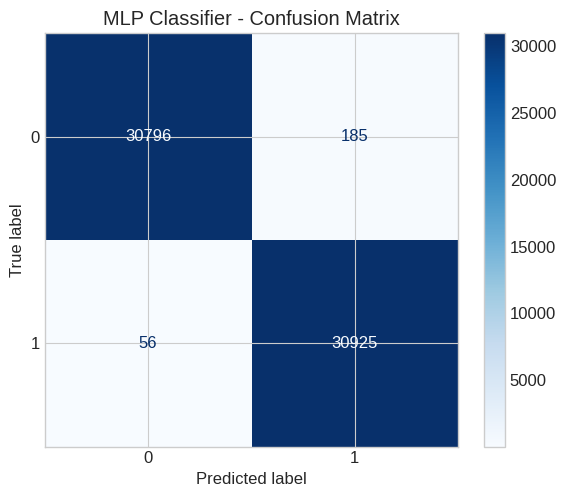

In [52]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title('MLP Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

- ROC Curve

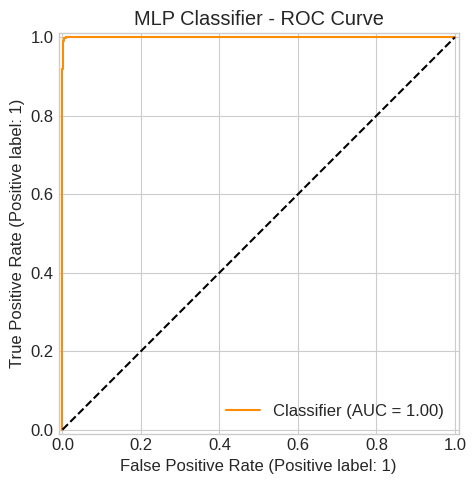

In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('MLP Classifier - ROC Curve')
plt.tight_layout()
plt.show()

- Training Loss Curve

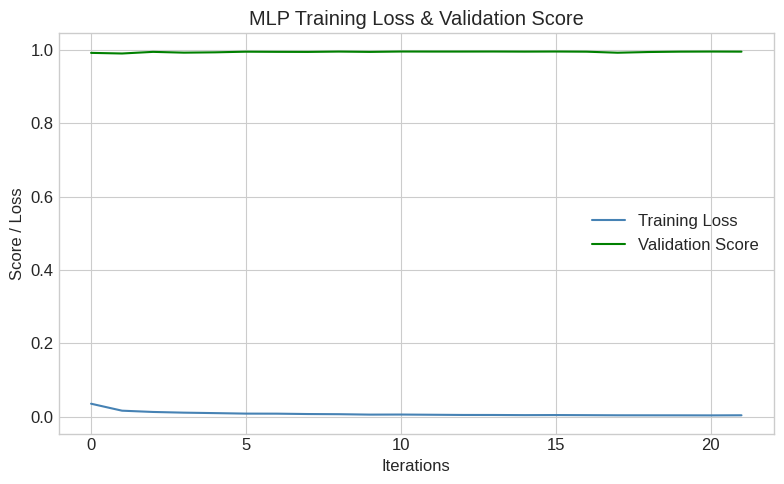

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label='Training Loss', color='steelblue')
plt.plot(mlp.validation_scores_, label='Validation Score', color='green')
plt.title('MLP Training Loss & Validation Score')
plt.xlabel('Iterations')
plt.ylabel('Score / Loss')
plt.legend()
plt.tight_layout()
plt.show()

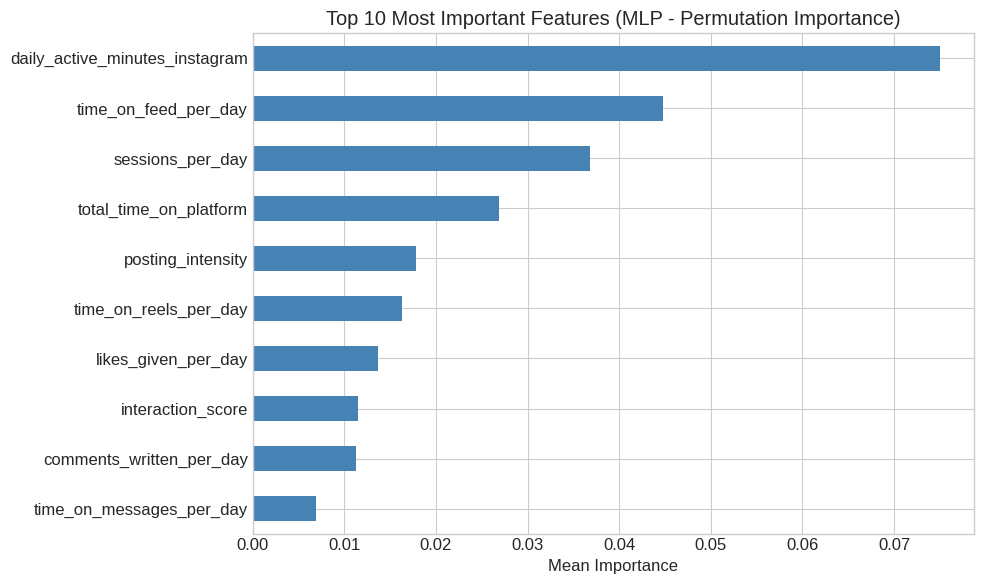

daily_active_minutes_instagram    0.074977
time_on_feed_per_day              0.044760
sessions_per_day                  0.036821
total_time_on_platform            0.026887
posting_intensity                 0.017813
time_on_reels_per_day             0.016279
likes_given_per_day               0.013631
interaction_score                 0.011539
comments_written_per_day          0.011268
time_on_messages_per_day          0.006916
dtype: float64


In [ ]:
perm = permutation_importance(mlp, x_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_names = df_balanced.drop(columns=['viral']).columns
perm_importance = pd.Series(perm.importances_mean, index=feature_names)
perm_importance = perm_importance.drop('user_engagement_score', errors='ignore')

top10 = perm_importance.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features (MLP - Permutation Importance)')
plt.xlabel('Mean Importance')
plt.tight_layout()
plt.show()

print(top10.sort_values(ascending=False))

- Save mlp model, scaler, balanced dataset and prediction results for further use or deployment

In [ ]:
joblib.dump(mlp, 'mlp_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved!")

df_balanced.to_csv('balanced_dataset.csv', index=False)
print("Balanced dataset saved!")

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'probability': y_prob
})
results_df.to_csv('mlp_predictions.csv', index=False)
print("Predictions saved!")

print("\nAll files saved")